In [1]:
import pandas as pd


In [2]:
df = pd.read_csv("../../Datasets/insurance_data.csv")
df.head(5)

,age,has_insurance
0,18,0
1,19,0
2,20,0
3,22,0
4,23,0


In [3]:
import os

os.getcwd()

'C:\\Users\\Shaik\\ML-Foundations\\Classification\\LogisticRegression'

In [4]:
import os

print(os.listdir("../"))

['.ipynb_checkpoints', 'LogisticRegression']


In [5]:
os.listdir("../../")

['.git',
 '.ipynb_checkpoints',
 'Classification',
 'Code',
 'Datasets',
 'Notes',
 'README.md']

In [6]:
#make a scatter plot
import matplotlib.pyplot as plt

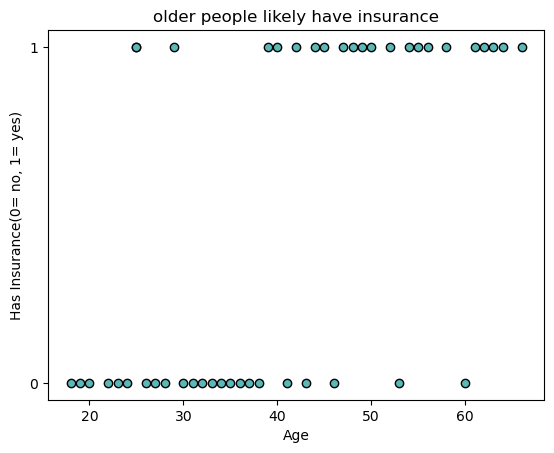

In [7]:
plt.scatter(df.age, df.has_insurance, color= "#5BB8B8", edgecolors="k")
plt.xlabel("Age")
plt.ylabel("Has Insurance(0= no, 1= yes)")
plt.title("older people likely have insurance")
plt.yticks([0, 1])
plt.show()

In [8]:
#using train_test 
from sklearn.model_selection import train_test_split

In [9]:
X= df[['age']]
y= df['has_insurance']

X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape

((36, 1), (9, 1))

In [10]:
X.shape

(45, 1)

In [11]:
df.shape

(45, 2)

In [12]:
#importing logisticregression and training using on train data

from sklearn.linear_model import LogisticRegression

model= LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [13]:
#now predicting model

age= pd.DataFrame({'age':[22, 56, 89]})
model.predict(age)

array([0, 1, 1], dtype=int64)

In [14]:
model.predict_proba(age)

array([[0.89109596, 0.10890404],
       [0.11462033, 0.88537967],
       [0.00230857, 0.99769143]])

In [15]:
model.coef_, model.intercept_

(array([[0.12195225]]), array([-4.78493436]))

In [18]:
import math

def sigmoid(x):
    return 1/ (1+ math.exp(-x))

def prediction_function(age):
    z= model.coef_[0][0] * age +model.intercept_[0]
    y= sigmoid(z)
    return y

prediction_function(60)

0.9263685791541548

In [19]:
7/9

0.7777777777777778

In [20]:
#model evalutaion

model.score(X_test, y_test)


0.7777777777777778

In [21]:
X_test

,age
39,60
25,43
26,44
43,64
35,54
41,62
4,23
12,30
8,26


In [22]:
model.predict(X_test)

array([1, 1, 1, 1, 1, 1, 0, 0, 0], dtype=int64)

In [23]:
y_test

39    0
25    0
26    1
43    1
35    1
41    1
4     0
12    0
8     0
Name: has_insurance, dtype: int64

In [24]:
7/9

0.7777777777777778

In [28]:
#using other methods to evaluate our model

from sklearn.metrics import classification_report

y_pred= model.predict(X_test)

report= classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.60      0.75         5
           1       0.67      1.00      0.80         4

    accuracy                           0.78         9
   macro avg       0.83      0.80      0.77         9
weighted avg       0.85      0.78      0.77         9



In [26]:
X_test.shape

(9, 1)

In [27]:
y_test.to_list(), y_pred

([0, 0, 1, 1, 1, 1, 0, 0, 0], array([1, 1, 1, 1, 1, 1, 0, 0, 0], dtype=int64))

In [32]:
#confusion metrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm= confusion_matrix(y_test, y_pred)
cm

array([[3, 2],
       [0, 4]], dtype=int64)

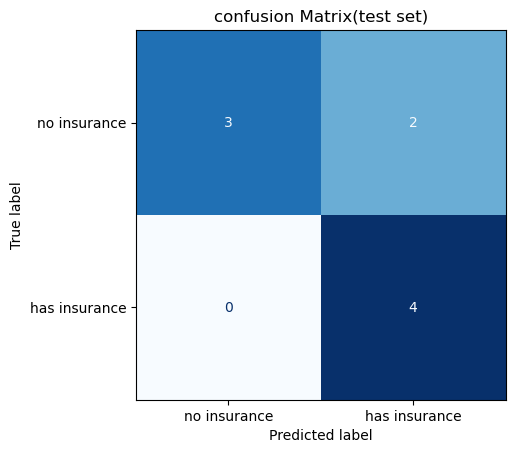

In [36]:
#displying confusion matrix

disp= ConfusionMatrixDisplay(
    confusion_matrix= cm,
    display_labels=['no insurance', 'has insurance']
)
disp.plot(cmap= 'Blues', colorbar= False)
plt.title('confusion Matrix(test set)')
plt.show()